In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, gamma


# **Repaso : Introducción a Estadística Bayesiana**

La idea de estos ejercicios es repasar algunos conceptos necesarios antes de trabajar con el modelo Beta-Binomial.

En particular, vamos a conectar cuatro ideas:

1. Modelo Bernoulli/Binomial.
2. Verosimilitud.
3. Teorema de Bayes en un caso discreto.
4. Distribución Beta como prior para una probabilidad desconocida.

Estos ejercicios funcionan como puente para entender luego el modelo:

$$
Y \mid \theta \sim \text{Binomial}(n,\theta),
\qquad
\theta \sim \text{Beta}(\alpha,\beta).
$$


In [1]:
# Función de probabilidad Binomial

def binomial_pmf(y, n, theta):
    return comb(n, y) * theta**y * (1-theta)**(n-y)

# Densidad Beta

def beta_pdf(theta, alpha, beta):
    constante = gamma(alpha + beta) / (gamma(alpha) * gamma(beta))
    return constante * theta**(alpha - 1) * (1 - theta)**(beta - 1)


## **Ejercicio 1:** Variable Bernoulli y distribución Binomial

Se lanza una moneda $n=10$ veces. Sea $Y$ la cantidad de caras observadas.

1. ¿Qué valores puede tomar $Y$?
2. Si la probabilidad de cara es $\theta$, ¿qué distribución tiene $Y$?
3. Escribir la función de probabilidad de $Y$.
4. Si se observan $y=7$ caras, calcular la proporción observada.

**Objetivo del ejercicio:** recordar cómo modelizamos datos de conteo cuando observamos una cantidad de éxitos en $n$ ensayos.


In [ ]:
from math import comb

n = 10

# 1
Y = {0,1,2,3,4,5,6,7,8,9,10}

#2
'''
Y ~ Binomial (n, theta)
'''

#3
'''
P(Y=y) =  comb(n y) * theta**y * (1-theta)**(n-y)
'''

#4
'''
n = 10 , y = 7

proporcion = 7/10= 0.7
'''



'\nn = 10 , y = 7\n\nproporcion = 7/10= 0.7\n'


## **Ejercicio 2:** Verosimilitud

Supongamos que se lanzan $10$ monedas y se observan $7$ caras.

1. Escribir la probabilidad de observar esos datos si la probabilidad de cara es $\theta$.
2. Escribir la verosimilitud $L(\theta)$.
3. Evaluar, sin necesidad de normalizar, qué valor parece más compatible con los datos:

$$
\theta=0.3,\qquad \theta=0.5,\qquad \theta=0.7.
$$

**Objetivo del ejercicio:** ver que la verosimilitud mide qué tan compatibles son distintos valores de $\theta$ con los datos observados.


In [16]:
n = 10
y = 7

# 1
'''
P(Y=7 | theta) =  comb(10, 7) * theta**7 * (1-theta)**(3)
'''

#2
'''
L(theta) = P(datos|theta) = P(Y=7 | theta) = comb(10, 7) * theta**7 * (1-theta)**(3)
                                           ∝ theta**7 * (1-theta)**3
'''

#3
''' 

'''
from math import comb

thetas = [0.3,0.5,0.7]
verosimilitudes = []

print ('datos: y=',y)
for i,theta in enumerate(thetas):
    vero = theta **7 * (1-theta)**3
    verosimilitudes.append(vero)
    print(theta, round(vero,5))

print(f'maximiza la verosimilitud el theta: {thetas[np.argmax(verosimilitudes)]}')



datos: y= 7
0.3 8e-05
0.5 0.00098
0.7 0.00222
maximiza la verosimilitud el theta: 0.7



## **Ejercicio 3:** Teorema de Bayes en un caso discreto

Supongamos que antes de observar datos creemos que la moneda puede tener alguno de estos valores de $\theta$:

$$
\theta \in \{0.3,0.5,0.7\}.
$$

Además, asignamos las siguientes probabilidades previas:

$$
P(\theta=0.3)=0.2,
\qquad
P(\theta=0.5)=0.5,
\qquad
P(\theta=0.7)=0.3.
$$

Se lanzan $10$ veces y se observan $7$ caras.

1. Calcular la verosimilitud de los datos para cada valor de $\theta$.
2. Calcular valores proporcionales a la posterior usando:

$$
p(\theta\mid y) \propto p(y\mid \theta)p(\theta).
$$

3. Normalizar para obtener probabilidades posteriores.

**Objetivo del ejercicio:** aplicar Bayes en un caso discreto antes de pasar al caso continuo con una distribución Beta.


In [25]:
thetas = [0.3, 0.5, 0.7]

priors = [0.2, 0.5, 0.3]

n = 10 
y = 7

#1
'''
L(theta)=P(datos|theta)= P(y=7|theta) = comb(10,7) * theta**7 * (1-theta)**3
                                      ∝ theta**7 * (1-theta)**3
'''
verosimilitudes = [theta**7 * (1-theta)**3 for theta in thetas]
print('verosimilitudes:',verosimilitudes)

# 2
posteriores = [vero*prior for vero,prior in zip(verosimilitudes,priors)]

print('posteriores',posteriores)

# 3

const_normalizacion = np.sum(posteriores)

posteriores_normalizadas = posteriores/const_normalizacion

print('posteriores normalizadas:',posteriores_normalizadas)


verosimilitudes: [7.501409999999996e-05, 0.0009765625, 0.0022235661]
posteriores [1.5002819999999993e-05, 0.00048828125, 0.00066706983]
posteriores normalizadas: [0.01281905 0.41720821 0.56997275]



## **Ejercicio 4:** Distribución Beta como prior

Considerar las siguientes distribuciones a priori para una probabilidad desconocida $\theta$:

$$
\theta \sim \text{Beta}(1,1),
$$

$$
\theta \sim \text{Beta}(8,8),
$$

$$
\theta \sim \text{Beta}(2,6).
$$

1. Calcular la media de cada prior usando:

$$
E(\theta)=\frac{\alpha}{\alpha+\beta}.
$$

2. Indicar cuál prior representa una creencia centrada en $0.5$.
3. Indicar cuál prior favorece valores bajos de $\theta$.
4. Comparar $\text{Beta}(1,1)$ y $\text{Beta}(8,8)$: ¿cuál parece más informativo?

**Objetivo del ejercicio:** interpretar la distribución Beta como una distribución previa para una probabilidad desconocida.


In [31]:
import preliz as pz
import matplotlib.pyplot as plt

medias prior: [0.5, 0.5, 0.25]


c:\Users\MAURICIO\Downloads\Inferencia 2\.venv\Lib\site-packages\pytensor\link\numba\dispatch\basic.py:214: UserWarning: Numba will use object mode to run XlogY0's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


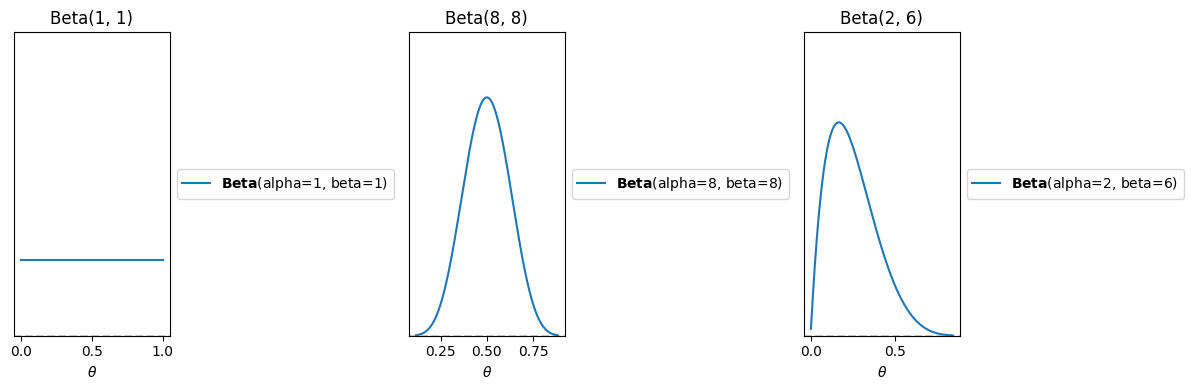

In [ ]:


priors = [(1,1),(8,8),(2,6)]

# 1
medias_prior = [alfa / (alfa + beta) for alfa,beta in priors]
print('medias prior:', medias_prior)

# 2
# El prior beta(8,8) y el (1,1)

#3

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for (a, b), ax in zip(priors, axes):
    pz.Beta(a, b).plot_pdf(ax=ax)
    ax.set_title(f"Beta({a}, {b})", fontsize=12)
    ax.set_xlabel(r"$\theta$")
    ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

In [ ]:
#3 la beta(2,6)

#4 
# el beta (8,8) es mas informativo, indica que el prior esta centrado alrededor del 0.5


## **Ejercicio 5:** ¿Por qué la posterior también es Beta?

Supongamos que observamos $Y=y$ éxitos en $n$ ensayos, donde

$$
Y \mid \theta \sim \text{Binomial}(n,\theta).
$$

Además, suponemos que la probabilidad desconocida $\theta$ tiene una distribución previa Beta:

$$
\theta \sim \text{Beta}(\alpha,\beta).
$$

Usando el Teorema de Bayes, demostrar que la distribución posterior de $\theta$ también es una distribución Beta, es decir:

$$
\theta \mid y \sim \text{Beta}(\alpha+y,\beta+n-y).
$$

Responder:

1. Escribir la verosimilitud $p(y\mid \theta)$.
2. Escribir la densidad previa $p(\theta)$, ignorando la constante de normalización.
3. Aplicar el Teorema de Bayes en forma proporcional:

$$
p(\theta\mid y)\propto p(y\mid \theta)p(\theta).
$$

4. Agrupar las potencias de $\theta$ y de $1-\theta$.
5. Identificar la forma de la distribución posterior.

**Objetivo del ejercicio:** comprender por qué la distribución Beta es conjugada de la distribución Binomial.



In [ ]:
#1
# verosimilitud P(y|theta) = comb(n,y) * theta**y * (1-theta) **(n-y) 
#                          ∝ theta**y * (1-theta) **(n-y)

#
# p(theta) = theta**(alpha-1) * (1-theta)**(beta-1)

# 3 y 4
# p(theta|y) ∝ theta**(y+alpha -1) * (1-theta)**(n - y + beta -1)

#5
# P(theta|y) ~ beta(y+alpha, n-y+beta)